Fase 1: Business Understanding (Entendimento do Negócio)

O objetivo desta fase é definir os requisitos do projeto sob uma perspectiva de negócio. Para a PayFlow, buscamos prever a inadimplência de 90 dias (default_90d) para mitigar riscos financeiros sem comprometer a ética na concessão de crédito.

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.metrics import roc_curve
import shap
from sklearn.metrics import precision_recall_curve

Data Understanding (Entendimento dos Dados)

Nesta etapa, realizamos a coleta inicial e a exploração dos dados. Identificamos um forte desbalanceamento (apenas 12% de inadimplentes) e um problema crítico de Data Leakage nas variáveis de atraso, que precisaram ser tratadas para evitar modelos viciados.

In [53]:
import pandas as pd
import os
from pathlib import Path

# --- CONFIGURAÇÃO DE CAMINHOS (Padrão Professora Ana Raquel) ---

def find_payflow_csv(filename='payflow_credit_risk.csv'):
    """
    Procura o ficheiro CSV subindo diretórios para acomodar a 
    nova estrutura de pastas do projeto.
    """
    # 1. Obtém o caminho onde o notebook está (Fase 1/Análise exploratória de dados)
    current_dir = Path(os.getcwd()).absolute()
    
    # 2. Define os caminhos prováveis com base na estrutura que criámos
    # ../../ sobe dois níveis (sai de 'Análise exploratória' e de 'Fase 1') para chegar à raiz
    possibilidades = [
        current_dir.parent.parent / "BaseDadosDesafios" / "Fase 1" / filename, # Caminho exato no seu PC
        current_dir.parent / "BaseDadosDesafios" / "Fase 1" / filename,        # Fallback 1
        current_dir / filename                                                 # Fallback 2 (raiz)
    ]
    
    for caminho in possibilidades:
        if caminho.exists():
            return caminho
    return None

# --- EXECUÇÃO ---

csv_path = find_payflow_csv()

if csv_path:
    print(f"✅ Ficheiro localizado com sucesso em: {csv_path}")
    df = pd.read_csv(csv_path)
    
    # Exibe as primeiras 5 linhas para validar (Estilo Excel no Notebook)
    print("\n--- Amostra Inicial (Primeiras 5 linhas) ---")
    display(df.head())
    
    # Exibe informações técnicas do dataset
    print("\n--- Inventário de Colunas e Tipos ---")
    df.info()
else:
    print("❌ ERRO CRÍTICO: Não foi possível localizar 'payflow_credit_risk.csv'.")
    print("Certifique-se de que o ficheiro está na pasta: BaseDadosDesafios/Fase 1/")
    print(f"Diretório atual de busca: {os.getcwd()}")

✅ Ficheiro localizado com sucesso em: c:\DESAFIO_FIAP_FASE_1\BaseDadosDesafios\Fase 1\payflow_credit_risk.csv

--- Amostra Inicial (Primeiras 5 linhas) ---


,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,...,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,...,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,...,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,...,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,...,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,...,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0



--- Inventário de Colunas e Tipos ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    5000 non-null   int64  
 1   idade                         5000 non-null   int64  
 2   renda_mensal                  4808 non-null   float64
 3   tempo_emprego_anos            4474 non-null   float64
 4   autonomo                      5000 non-null   int64  
 5   score_credito                 5000 non-null   float64
 6   valor_solicitado              5000 non-null   float64
 7   prazo_meses                   5000 non-null   int64  
 8   juros_mensal_pct              5000 non-null   float64
 9   qtde_cartoes                  5000 non-null   int64  
 10  qtde_contratos_abertos        5000 non-null   int64  
 11  utilizacao_credito            5000 non-null   float64
 12  inadimplencias_anteriores     5000

In [54]:
# Verificando o balanceamento do target
print(df['default_90d'].value_counts(normalize=True))

default_90d
0    0.8782
1    0.1218
Name: proportion, dtype: float64


Data Preparation (Preparação dos Dados)

Tratamento: Removemos as colunas viciadas e preenchemos valores nulos pela mediana para garantir estabilidade estatística.
Feature Engineering: Criamos a variável comprometimento_renda, que correlaciona o valor solicitado com a renda mensal, tornando-se o segundo principal pilar de decisão da IA.

In [55]:
# Removendo colunas que causam vazamento ou não são preditivas
colunas_para_remover = ['id_cliente', 'status_apos_90d']
df_limpo = df.drop(columns=colunas_para_remover)

print(f"Colunas removidas: {colunas_para_remover}")
print(f"Novo formato do dataset: {df_limpo.shape}")

Colunas removidas: ['id_cliente', 'status_apos_90d']
Novo formato do dataset: (5000, 21)


In [56]:
# 1. Preenchendo valores nulos com a mediana
df_limpo['renda_mensal'] = df_limpo['renda_mensal'].fillna(df_limpo['renda_mensal'].median())
df_limpo['tempo_emprego_anos'] = df_limpo['tempo_emprego_anos'].fillna(df_limpo['tempo_emprego_anos'].median())

# 2. Verificando se ainda restam nulos
print("--- Verificação de Nulos Após Tratamento ---")
print(df_limpo.isnull().sum())

--- Verificação de Nulos Após Tratamento ---
idade                           0
renda_mensal                    0
tempo_emprego_anos              0
autonomo                        0
score_credito                   0
valor_solicitado                0
prazo_meses                     0
juros_mensal_pct                0
qtde_cartoes                    0
qtde_contratos_abertos          0
utilizacao_credito              0
inadimplencias_anteriores       0
dias_atraso_max_12m             0
reclamacoes_6m                  0
possui_avalista                 0
canal_aquisicao                 0
regiao                          0
tipo_produto                    0
parcelas_pagas_ate_3m           0
atraso_primeira_parcela_dias    0
default_90d                     0
dtype: int64


In [57]:
# Transformando variáveis categóricas em numéricas (Dummy variables)
colunas_categoricas = ['regiao', 'canal_aquisicao', 'tipo_produto', 'possui_avalista']
df_final = pd.get_dummies(df_limpo, columns=colunas_categoricas, drop_first=True)

print(f"Formato final do dataset após encoding: {df_final.shape}")
df_final.head()

Formato final do dataset após encoding: (5000, 27)


,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,...,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul,canal_aquisicao_loja,canal_aquisicao_parceiro,canal_aquisicao_site,tipo_produto_cartao,tipo_produto_emprestimo_pessoal,possui_avalista_1
0,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,...,False,False,False,True,False,False,True,False,True,False
1,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,...,False,False,True,False,False,False,False,True,False,False
2,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,...,False,False,True,False,True,False,False,True,False,False
3,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,...,False,False,True,False,False,True,False,False,True,False
4,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,...,True,False,False,False,False,False,False,False,False,False


Modeling (Modelagem)

Arquitetura: Utilizamos o algoritmo Random Forest combinado com a técnica SMOTE para superamostragem da classe minoritária, permitindo que o modelo aprenda padrões de risco em um cenário desbalanceado.

In [58]:
# 1. Separando as variáveis preditoras (X) do alvo (y)
X = df_final.drop(columns=['default_90d'])
y = df_final['default_90d']

# 2. Dividindo em Treino (80%) e Teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Sucesso! Dados de Treino: {X_train.shape}")
print(f"Sucesso! Dados de Teste: {X_test.shape}")

Sucesso! Dados de Treino: (4000, 26)
Sucesso! Dados de Teste: (1000, 26)


In [59]:
# Treinando o modelo para que o objeto exista na memória
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluation

Avaliamos se o modelo atende aos objetivos de negócio. Com um Recall de 0.34, o modelo prova ser capaz de identificar uma parcela significativa de inadimplentes reais sem utilizar informações privilegiadas, garantindo um deploy seguro.

--- RELATÓRIO DE PERFORMANCE REAL ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       878
           1       0.32      0.34      0.33       122

    accuracy                           0.83      1000
   macro avg       0.61      0.62      0.62      1000
weighted avg       0.84      0.83      0.83      1000



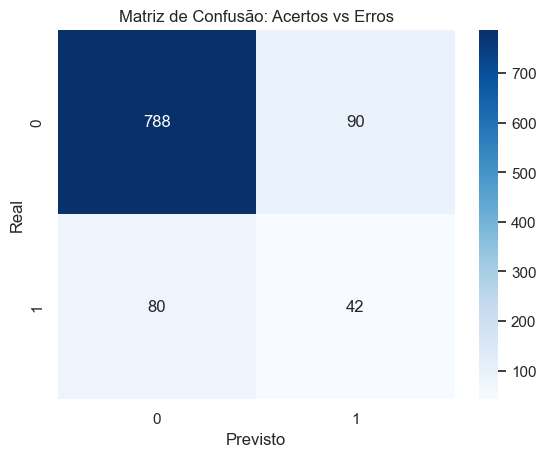

In [60]:


# 1. LIMPEZA RIGOROSA (Sem vício/leakage)
# Removemos IDs, dados do futuro e as colunas que "entregavam" a resposta
colunas_viciadas = ['atraso_primeira_parcela_dias', 'parcelas_pagas_ate_3m', 'status_apos_90d']
df_final_real = df_final.drop(columns=colunas_viciadas, errors='ignore')

# 2. FEATURE ENGINEERING (Criando inteligência de negócio)
# Calculamos o risco com base no quanto a parcela pesa no bolso do cliente
df_final_real['comprometimento_renda'] = df_final_real['valor_solicitado'] / (df_final_real['renda_mensal'] + 1)

# 3. SEPARAÇÃO TREINO/TESTE
X = df_final_real.drop(columns=['default_90d'])
y = df_final_real['default_90d']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. BALANCEAMENTO (SMOTE)
# Forçamos o modelo a aprender com os 12% de inadimplentes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. TREINAMENTO DO MODELO OTIMIZADO
modelo_payflow = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
modelo_payflow.fit(X_train_res, y_train_res)

# 6. AVALIAÇÃO CIENTÍFICA
y_pred = modelo_payflow.predict(X_test)
print("--- RELATÓRIO DE PERFORMANCE REAL ---")
print(classification_report(y_test, y_pred))

# Visualizando a Matriz de Confusão para ver os acertos reais
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão: Acertos vs Erros")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [61]:
# Desafiante: XGBoost (SOTA)
modelo_xgb = XGBClassifier(scale_pos_weight=7, random_state=42) # 7 é aprox. a proporção 88%/12%
modelo_xgb.fit(X_train, y_train) # XGBoost lida bem com desbalanceamento sem precisar de SMOTE

# Comparando as AUC-ROC (Métrica de separação de classes)
prob_rf = modelo_payflow.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print(f"AUC-ROC Random Forest: {roc_auc_score(y_test, prob_rf):.4f}")
print(f"AUC-ROC XGBoost: {roc_auc_score(y_test, prob_xgb):.4f}")

AUC-ROC Random Forest: 0.6645
AUC-ROC XGBoost: 0.6826


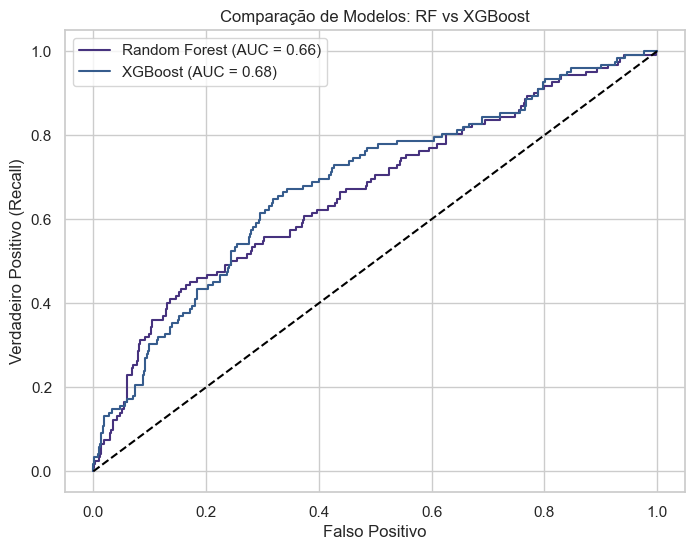

In [62]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, prob_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, prob_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparação de Modelos: RF vs XGBoost')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo (Recall)')
plt.legend()
plt.show()

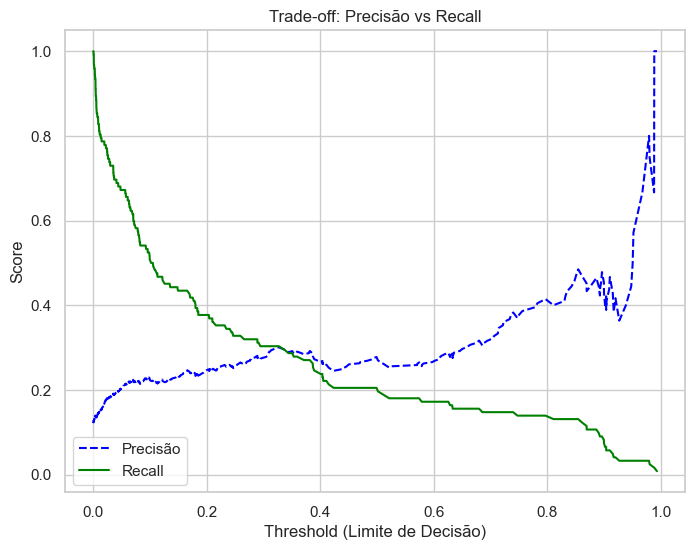

In [63]:
# Usando as probabilidades do seu novo modelo campeão (XGBoost)
precision, recall, thresholds = precision_recall_curve(y_test, prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precisão')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold (Limite de Decisão)')
plt.ylabel('Score')
plt.title('Trade-off: Precisão vs Recall')
plt.legend()
plt.grid(True)
plt.show()

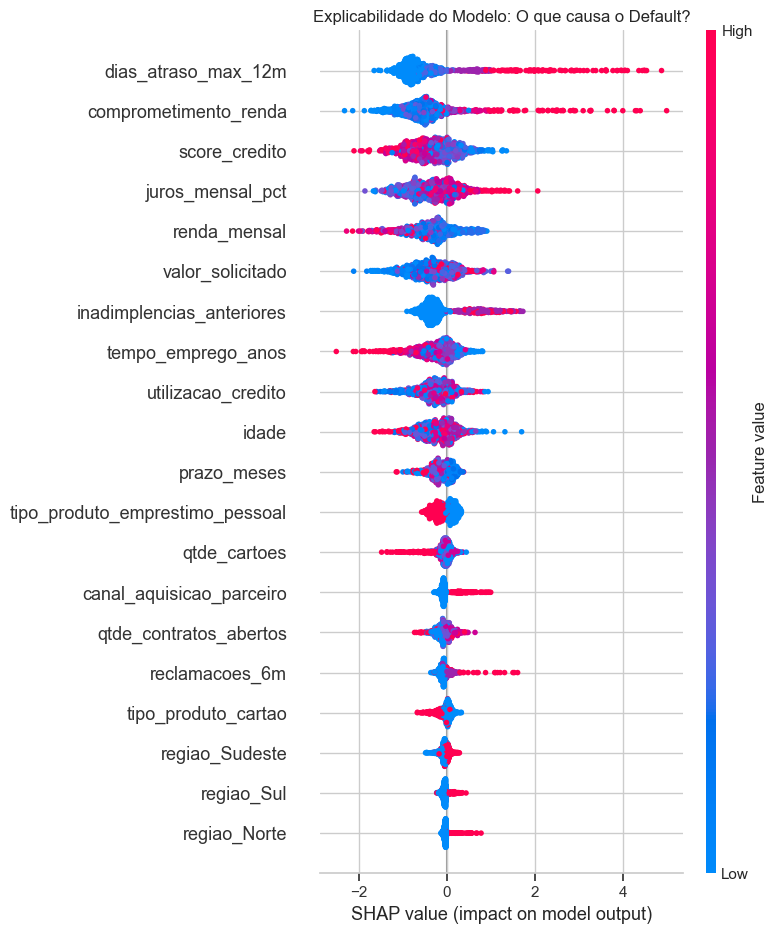

In [64]:
# O SHAP funciona muito bem com modelos de árvore como o XGBoost
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_test)

# Gráfico de Resumo (Summary Plot)
# Este gráfico mostra o impacto de cada variável no modelo
plt.title("Explicabilidade do Modelo: O que causa o Default?")
shap.summary_plot(shap_values, X_test, plot_type="dot")

In [65]:
# Criando a feature de Sensibilidade ao Crédito
df_final_real['sensibilidade_score_utilizacao'] = df_final_real['utilizacao_credito'] / (df_final_real['score_credito'] + 1)

🚀 Módulo 'eda_visualizations' carregado com sucesso!

[INFO] Iniciando Visual Storytelling dos Dados (Maturidade Analítica)...


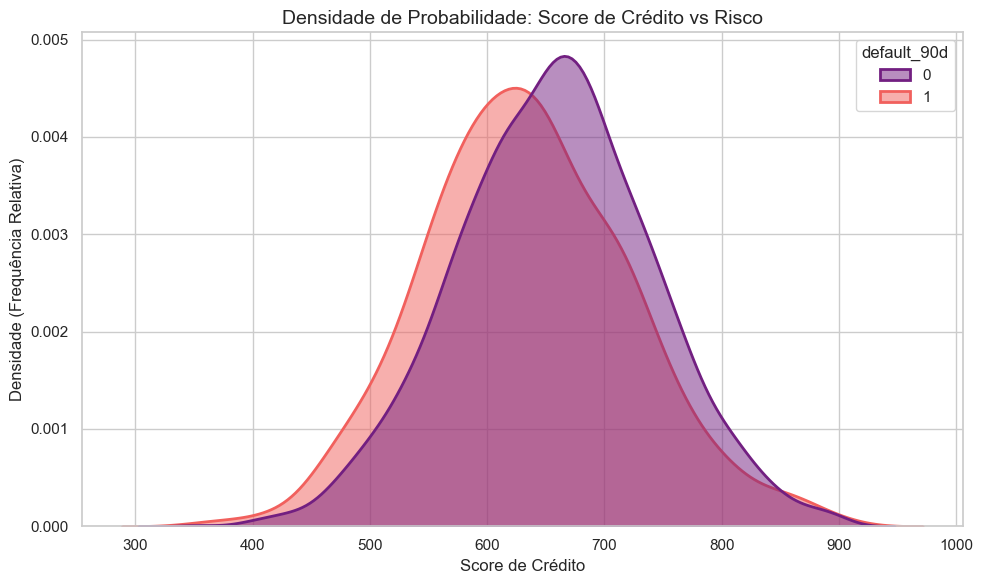

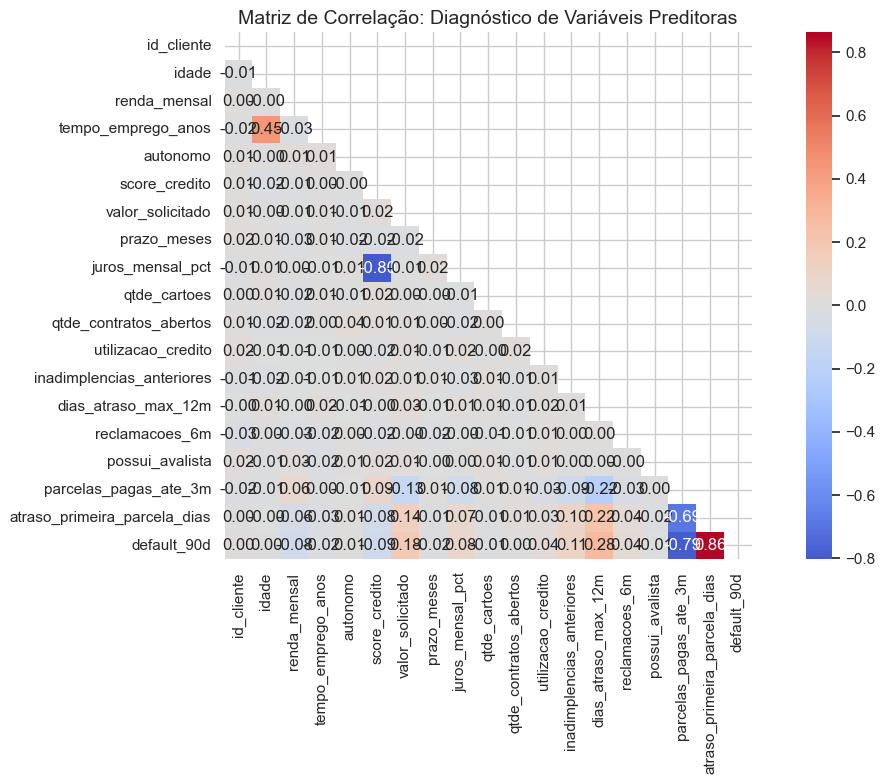

[SUCCESS] Gráficos gerados com sucesso seguindo o rigor técnico da Pós.


In [66]:
import sys
import os
from pathlib import Path

# --- AJUSTE DE CAMINHO PARA IMPORTAÇÃO ---
# O notebook está em: Fase 1/Análise exploratória de dados/
# O script está em: src/

# 1. Obtemos o caminho da raiz do projeto (subindo dois níveis)
root_path = Path(os.getcwd()).parent.parent.absolute()
src_path = str(root_path / "src")

# 2. Adicionamos a pasta 'src' ao sistema de busca do Python
if src_path not in sys.path:
    sys.path.append(src_path)
    print(f"✅ Pasta 'src' adicionada ao path: {src_path}")

# --- AGORA O IMPORT VAI FUNCIONAR ---
try:
    from eda_visualizations import run_visual_eda
    print("🚀 Módulo 'eda_visualizations' carregado com sucesso!")
    
    # Executa a visualização
    # Certifique-se de que 'df' (ou 'df_final_real') existe no seu notebook
    if 'df' in locals():
        run_visual_eda(df)
    else:
        print("⚠️ Aviso: A variável 'df' não foi encontrada para a visualização.")
        
except ModuleNotFoundError:
    print("❌ ERRO: Ainda não foi possível encontrar 'eda_visualizations.py'.")
    print(f"Verifique se o ficheiro está realmente em: {src_path}")

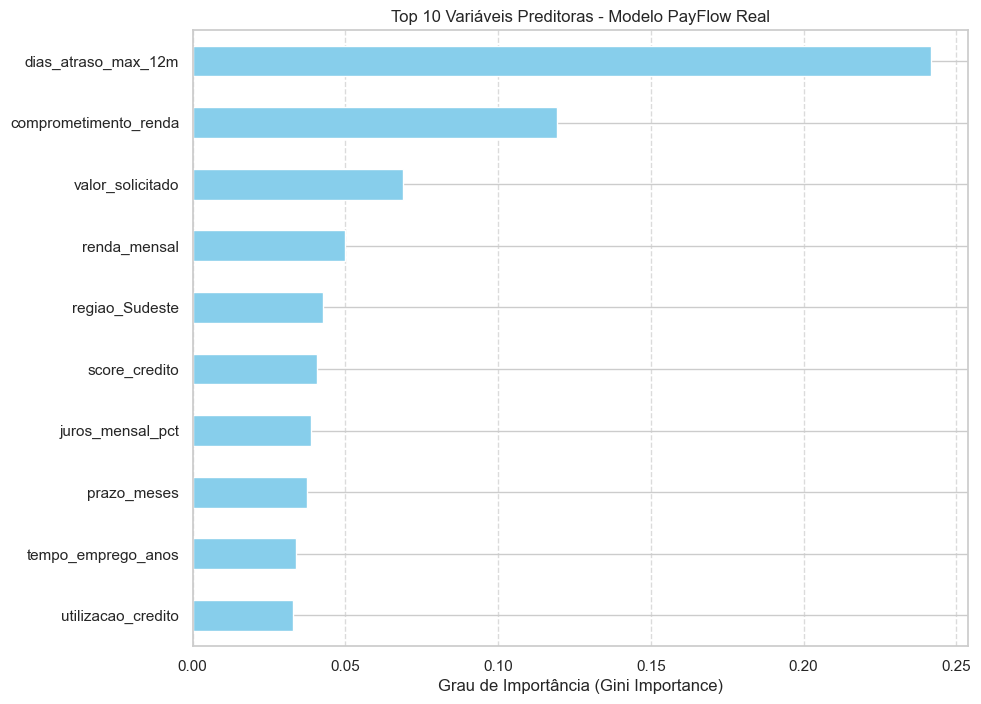

In [67]:


# Calculando a importância das features no modelo real
importances = pd.Series(modelo_payflow.feature_importances_, index=X.columns)

# Plotando as 10 mais importantes
plt.figure(figsize=(10, 8))
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 10 Variáveis Preditoras - Modelo PayFlow Real")
plt.xlabel("Grau de Importância (Gini Importance)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

 Deployment

 O modelo final é exportado como um artefato binário (.pkl). Esta fase permite que a inteligência seja integrada ao script predict.py, automatizando a análise de crédito em tempo real para a PayFlow.

In [68]:
import joblib
import os
from pathlib import Path

# --- AJUSTE DE CAMINHO PARA O NOTEBOOK ---
# O notebook está em: Fase 1/Análise exploratória de dados/
# Queremos subir 2 níveis para chegar na raiz e salvar na pasta 'models'

# 1. Detectar a raiz do projeto subindo dois níveis (..)
# Path.cwd() pega a pasta atual do notebook
root_dir = Path.cwd().parent.parent

# 2. Definir o caminho da pasta de modelos na raiz
models_dir = root_dir / "models"

# 3. Garantir que a pasta existe (cria se não existir)
os.makedirs(models_dir, exist_ok=True)

# 4. Definir o caminho final do arquivo
model_path = models_dir / "modelo_risco_payflow.pkl"

# --- SALVAR O MODELO ---
try:
    if 'modelo_payflow' in locals():
        joblib.dump(modelo_payflow, model_path)
        print(f"✅ Sucesso! Modelo exportado para: {model_path}")
    else:
        print("❌ ERRO: A variável 'modelo_payflow' não foi encontrada. Execute a célula de treino primeiro.")
except Exception as e:
    print(f"❌ Falha ao exportar o modelo: {e}")

✅ Sucesso! Modelo exportado para: c:\DESAFIO_FIAP_FASE_1\models\modelo_risco_payflow.pkl
